In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
df=pd.read_csv(r'C:\Machine Learning\medical_insurance_predictor\Datasets\medical_insurance.csv')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   str    
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   str    
 5   region    2772 non-null   str    
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 195.5 KB


In [4]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


C:\Users\INDUS LAPTOP\AppData\Local\Temp\ipykernel_17172\2119537381.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'],hist=False)


<Axes: xlabel='age', ylabel='Density'>

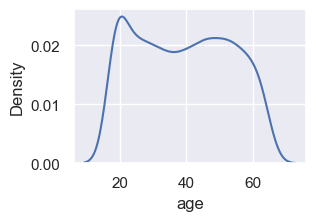

In [5]:
sns.set()
plt.figure(figsize=(3,2))
sns.distplot(df['age'],hist=False)

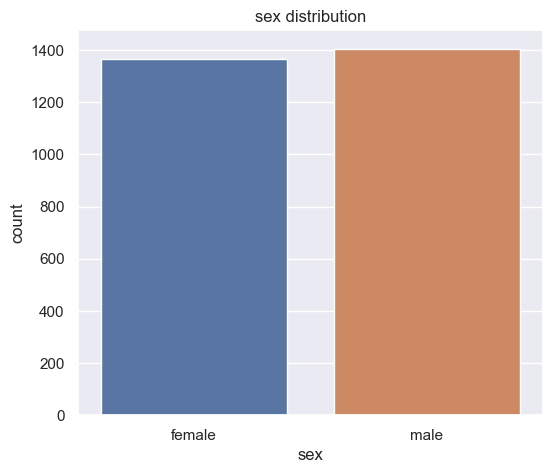

In [6]:
plt.figure(figsize=(6,5))
sns.countplot(x='sex',data=df,hue='sex')
plt.title("sex distribution")
plt.show()

C:\Users\INDUS LAPTOP\AppData\Local\Temp\ipykernel_17172\4168411822.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bmi'])


<Axes: xlabel='bmi', ylabel='Density'>

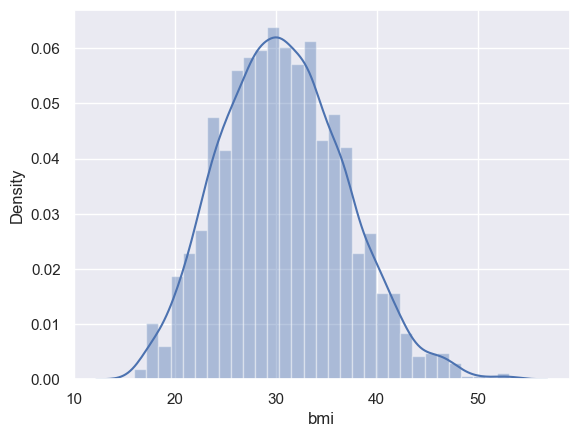

In [7]:
sns.distplot(df['bmi'])

<Axes: xlabel='children', ylabel='count'>

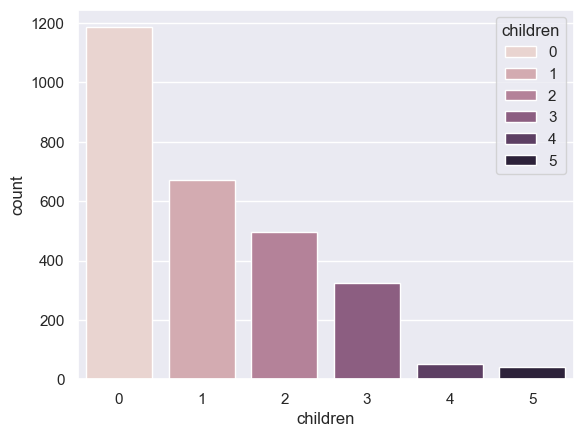

In [8]:
sns.countplot(x='children',data=df,hue='children')

<Axes: xlabel='smoker', ylabel='count'>

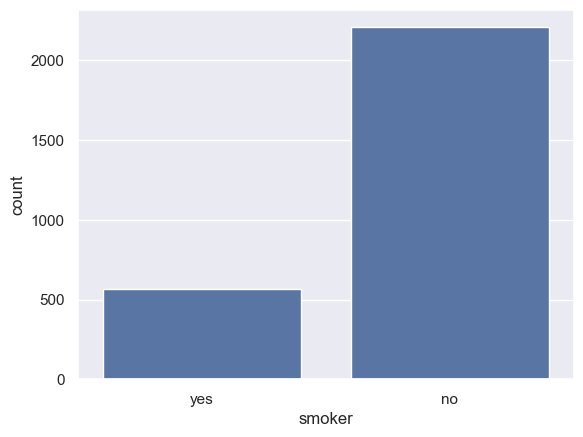

In [9]:
sns.countplot(x='smoker',data=df)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   str    
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   str    
 5   region    2772 non-null   str    
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 195.5 KB


C:\Users\INDUS LAPTOP\AppData\Local\Temp\ipykernel_17172\1319113370.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['charges'])


<Axes: xlabel='charges', ylabel='Density'>

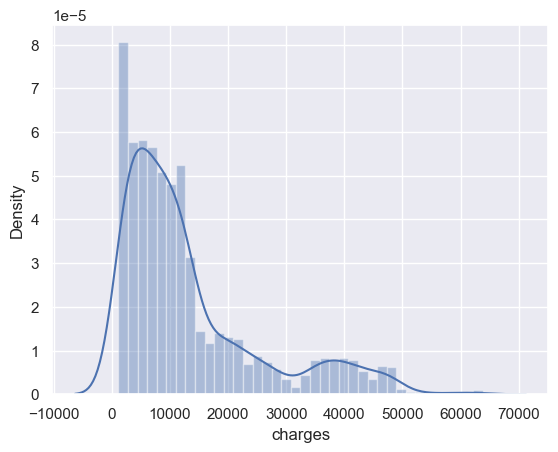

In [11]:
sns.distplot(df['charges'])

Encoding the categorical features

In [12]:
df['sex']=df['sex'].map({'male':1,'female':0})

In [13]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,yes,southwest,16884.92400
1,18,1,33.770,1,no,southeast,1725.55230
2,28,1,33.000,3,no,southeast,4449.46200
3,33,1,22.705,0,no,northwest,21984.47061
4,32,1,28.880,0,no,northwest,3866.85520


In [14]:
df['smoker']=df['smoker'].map({'yes':1,'no':0})

In [15]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [16]:
df['region']=df['region'].map({'southwest':0,'southeast':1,'northwest':2,'northeast':3})

In [17]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,0,16884.92400
1,18,1,33.770,1,0,1,1725.55230
2,28,1,33.000,3,0,1,4449.46200
3,33,1,22.705,0,0,2,21984.47061
4,32,1,28.880,0,0,2,3866.85520


Now Scaling the numerical features

In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scalar=StandardScaler()
features=['age', 'bmi', 'children']
df[features]=scalar.fit_transform(df[features])

In [20]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,-1.428353,0,-0.457114,-0.907084,1,0,16884.92400
1,-1.499381,1,0.500731,-0.083758,0,1,1725.55230
2,-0.789099,1,0.375085,1.562893,0,1,4449.46200
3,-0.433959,1,-1.304814,-0.907084,0,2,21984.47061
4,-0.504987,1,-0.297201,-0.907084,0,2,3866.85520


Train_Test Split

In [21]:
X=df.iloc[:,0:6]
y=df.iloc[:,-1]

In [22]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [23]:
X_train.head()

,age,sex,bmi,children,smoker,region
1864,-1.286297,1,1.003314,-0.907084,0,1
1997,-0.078818,0,0.668802,0.739567,0,0
1336,-1.286297,0,-0.799784,-0.907084,0,0
655,0.915577,0,-0.881372,0.739567,1,1
261,-1.357325,0,-0.630080,-0.083758,1,1


Training Linear Regression Model

In [24]:
lr=LinearRegression()

In [25]:
lr.fit(X_train,y_train)
y_predict= lr.predict(X_test)

In [26]:
r2=r2_score(y_test,y_predict)

In [27]:
r2

0.7398864322395977

Applying other model (RandomForest Regressor)


In [28]:
from sklearn.ensemble import RandomForestRegressor

In [29]:
rf=RandomForestRegressor()

In [30]:
rf.fit(X_train,y_train)
y_predict_rf= rf.predict(X_test)

In [31]:
r2_rf=r2_score(y_test,y_predict_rf)

In [32]:
r2_rf

0.9503232440119149

Now Saving models

In [33]:
import pickle

In [34]:
pickle.dump(rf,open('model.pkl','wb'))
pickle.dump(scalar,open('my_scalar.pkl','wb'))
